In [1]:
from Scripts.Random_forest_nested import *
import matplotlib.pyplot as plt
import pickle 

In [4]:
df = pd.read_excel('../SImulated_data/Clinical_synthetic.xlsx', index_col=0)
X,y=df.loc[:,['scaled_nox','scaled_no2','scaled_formaldehyd','scaled_acetone','scaled_acetald',
    'scaled_bc', 'scaled_PM25','no2_street', 'nox_street', 'pm25_street', 'gestational_age', 'lrti_1y',
       'genetic_risk_score_asthma']],df.verificeret_12y

In [5]:
list_parameters=["$NO_x$","$NO_2$","Formaldehyd","Acetone","Acetald","Black Carbon","$PM_{2.5}$","Street $NO_2$","Street $NO_x$","Street $PM_{2.5}$","Gestational age","LRTI","Asthma risk score"]

In [6]:
replace_dict=dict(zip(X.columns,list_parameters))
X=X.rename(columns=replace_dict)

In [7]:
replace_dict

{'scaled_nox': '$NO_x$',
 'scaled_no2': '$NO_2$',
 'scaled_formaldehyd': 'Formaldehyd',
 'scaled_acetone': 'Acetone',
 'scaled_acetald': 'Acetald',
 'scaled_bc': 'Black Carbon',
 'scaled_PM25': '$PM_{2.5}$',
 'no2_street': 'Street $NO_2$',
 'nox_street': 'Street $NO_x$',
 'pm25_street': 'Street $PM_{2.5}$',
 'gestational_age': 'Gestational age',
 'lrti_1y': 'LRTI',
 'genetic_risk_score_asthma': 'Asthma risk score'}

In [8]:
param_distributions = {
    'n_estimators':           [300],
    'max_depth':              randint(2, 6),
    'min_samples_leaf':       randint(10, 30),
    'max_features':           [0.4, 0.5, 0.6, 'sqrt'],
    'max_samples':            [0.5, 0.6, 0.7, 0.8],
    # class_weight removed
}
dataframe =nested_cross_calibrated_rf(
    X, y,
    Number_CV=2,
    number_split=3,
    n_neighbors_imputer=25,
    param_distributions=param_distributions,
    calibration_method="isotonic")



Fold 1/6  AUC=0.438  BSS=-0.062  ICI=0.071
Fold 2/6  AUC=0.458  BSS=-0.052  ICI=0.066
Fold 3/6  AUC=0.482  BSS=+0.009  ICI=0.046
Fold 4/6  AUC=0.539  BSS=-0.044  ICI=0.065
Fold 5/6  AUC=0.563  BSS=-0.012  ICI=0.026
Fold 6/6  AUC=0.529  BSS=+0.015  ICI=0.039


In [9]:
with open("../Performence/results_rf_12y.pkl", "wb") as f:
    pickle.dump(dataframe, f)

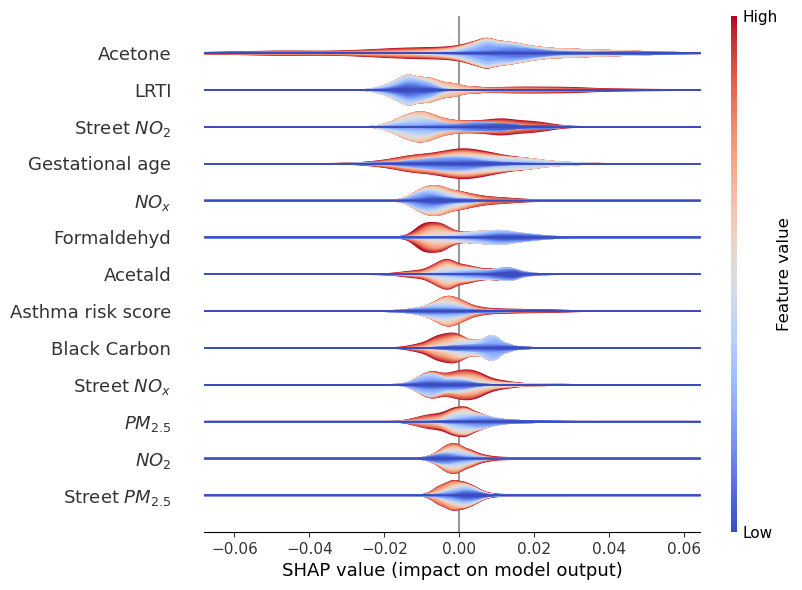

In [10]:

fig=shap.plots.violin(dataframe['shap_values_oof'],X ,plot_type="layered_violin",show=False)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
})
# increase pad to push title further away


plt.savefig('../Plots/shap_12.png',dpi=300,bbox_inches='tight')
